# Gold: engajamento (`governor_engagement`)

ADR [0022](../../docs/adr/0022-notebooks-de-diagnostico-medallion-separados-da-narrativa-do-tcc.md)
(issue [#128](https://github.com/Vini0606/Tecnicas-de-Ciencia-de-Dados-em-dados-do-Instagram/issues/128)).
Diagnóstico da tabela `governor_engagement` (+ `governor_engagement_history` para a evolução
temporal) -- gerada por `src/features/gold/engagement_aggregator.py`. Notebook estritamente
leitura via `DeltaRepository`, mesmo princípio da ADR
[0003](../../docs/adr/0003-desacoplar-modelagem-do-notebook-via-scripts-cli-com-checkpoint.md).

In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from config import settings
from src.repositories.delta_repository import DeltaRepository
from src.visualization.charts import plot_engagement_trend, plot_correlation_heatmap
from src.analysis.medallion_diagnostics import (
    completeness_summary,
    count_duplicate_rows,
    with_governor_metadata,
)

load_dotenv()
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

repo = DeltaRepository(gold_dir=settings.GOLD_DIR, silver_dir=settings.SILVER_DIR)

## 1. Carga + schema

`DeltaRepository.load_profiles()` lê `governor_engagement` apesar do nome (herdado de quando só
havia uma tabela de perfil na Gold) -- não é a Bronze/Silver de perfis, ver
`00_bronze_silver_overview.ipynb` para essas.

In [2]:
df_engagement = repo.load_profiles()
df_engagement.dtypes

id                                object
username                          object
fullName                          object
inputUrl                          object
followersCount                     int32
followsCount                       int32
postsCount                         int32
TOTAL ENGAJAMENTO                  int64
% ENGAJAMENTO                    float64
_WC_COMENTARIO                   float64
RECENCIA                         float64
FREQUENCIA                       float64
commentsSum                        int64
likesSum                           int64
count                              int64
minData                   datetime64[us]
maxData                   datetime64[us]
_run_id                           object
_generated_at        datetime64[us, UTC]
dtype: object

## 2. Completude

Cobertura por governador é sempre 1 linha por `inputUrl` nesta tabela (granularidade "1 por
perfil", diferente de `_history`) -- duplicatas aqui seriam um bug de agregação, não uma
possibilidade normal.

In [3]:
completude = completeness_summary(df_engagement)
print(f"linhas duplicadas (por inputUrl): {count_duplicate_rows(df_engagement, subset=['inputUrl'])}")
completude[completude['n_nulos'] > 0]

linhas duplicadas (por inputUrl): 0


,coluna,dtype,n_nulos,pct_nulos,n_unicos
15,minData,datetime64[us],1,3.7037,26
16,maxData,datetime64[us],1,3.7037,26


## 3. Distribuições univariadas das métricas-chave

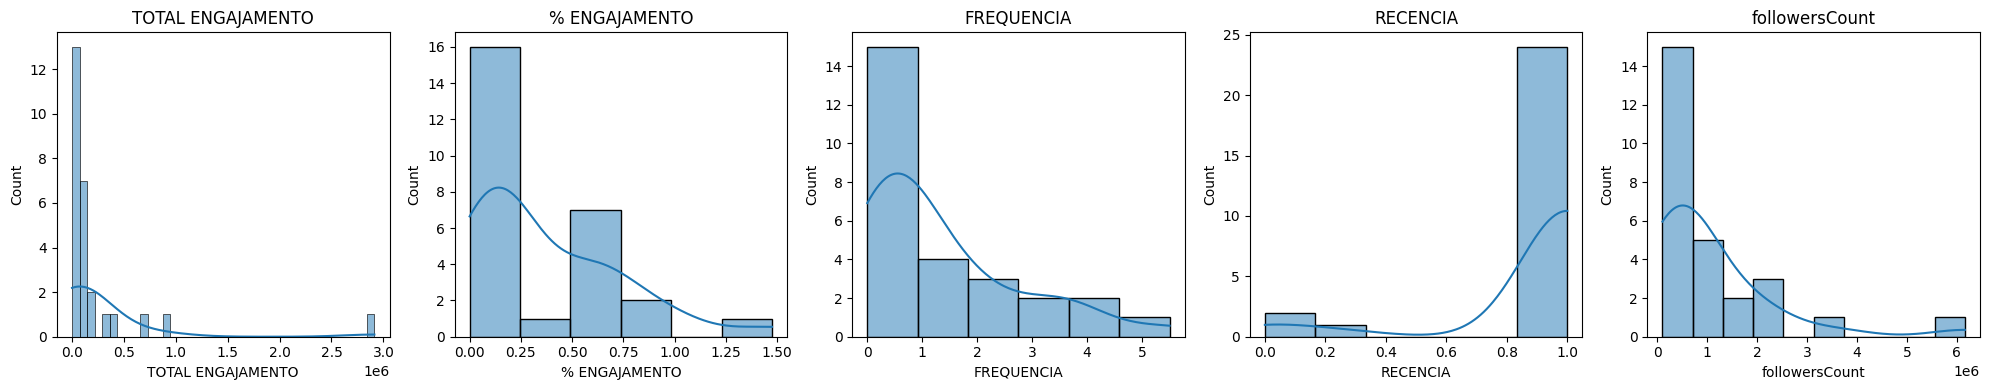

In [4]:
metricas_chave = ['TOTAL ENGAJAMENTO', '% ENGAJAMENTO', 'FREQUENCIA', 'RECENCIA', 'followersCount']

fig, axes = plt.subplots(1, len(metricas_chave), figsize=(4 * len(metricas_chave), 4))
for ax, coluna in zip(axes, metricas_chave):
    sns.histplot(df_engagement[coluna], kde=True, ax=ax)
    ax.set_title(coluna)
plt.tight_layout()
plt.show()

## 4. Evolução temporal (`governor_engagement_history`)

Reaproveita `plot_engagement_trend` de `src/visualization/charts.py` -- a mesma função já testada
(`tests/test_charts.py`) e usada pelo dashboard, uma linha por governador ao longo de `_generated_at`.

In [5]:
df_engagement_history = repo.load_engagement_history()
print(f"{df_engagement_history['_run_id'].nunique()} execuções acumuladas")

fig = plot_engagement_trend(
    df_engagement_history, y_col='TOTAL ENGAJAMENTO', title='TOTAL ENGAJAMENTO por execução'
)
fig

2 execuções acumuladas


## 5. Relação com covariáveis (partido/UF)

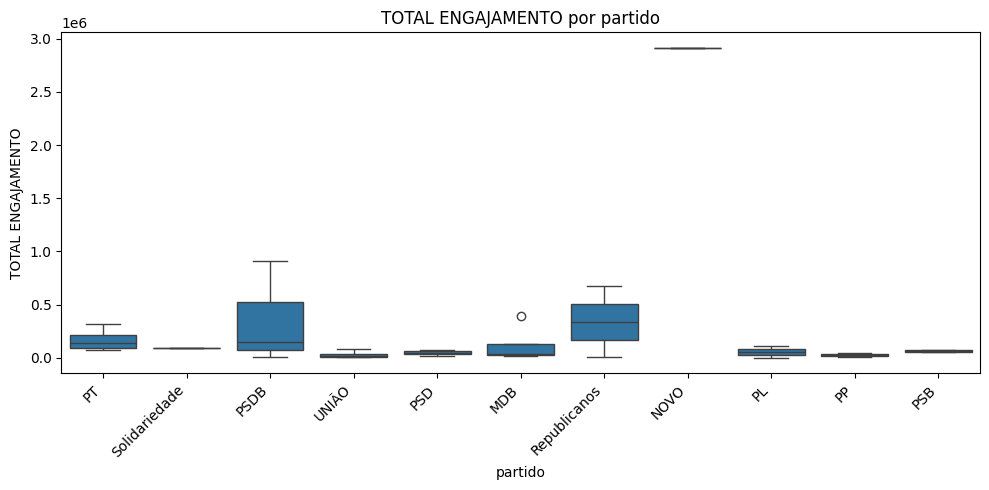

In [6]:
df_com_metadado = with_governor_metadata(df_engagement, repo.load_governors_metadata())

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_com_metadado, x='partido', y='TOTAL ENGAJAMENTO', ax=ax)
ax.set_title('TOTAL ENGAJAMENTO por partido')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
plot_correlation_heatmap(df_engagement[metricas_chave])

## 6. Outliers

Perfis mais de 2 desvios-padrão acima/abaixo da média de `% ENGAJAMENTO` -- sinalizados
explicitamente, não só visíveis num scatter/boxplot.

In [8]:
media = df_engagement['% ENGAJAMENTO'].mean()
desvio = df_engagement['% ENGAJAMENTO'].std()
outliers = df_engagement[
    (df_engagement['% ENGAJAMENTO'] - media).abs() > 2 * desvio
][['username', '% ENGAJAMENTO', 'TOTAL ENGAJAMENTO', 'followersCount']]
print(f'{len(outliers)} perfis fora de 2 desvios-padrão em % ENGAJAMENTO (média={media:.4f}, desvio={desvio:.4f})')
outliers.sort_values('% ENGAJAMENTO', ascending=False)

1 perfis fora de 2 desvios-padrão em % ENGAJAMENTO (média=0.3705, desvio=0.3665)


,username,% ENGAJAMENTO,TOTAL ENGAJAMENTO,followersCount
13,romeuzemaoficial,1.4743,2913625,3561392


## Nota de interpretação

`% ENGAJAMENTO` normaliza por `followersCount`, então um outlier aqui não é necessariamente o
governador mais engajado em termos absolutos (ver `TOTAL ENGAJAMENTO` ao lado) -- perfis com poucos
seguidores e um post viral pontual tendem a aparecer aqui, vale checar `count`/`FREQUENCIA` antes de
tratar como um padrão sustentado.